# Task: Pattern Detection

**Student Name:** Mykhailo Andrusiak  
**Country:** Switzerland  
**Semester term:** FS26  

## Day 6 - Technical Implementation

### Implementation Strategy

The Hough Line Transform algorithm is validated on a synthetic test image with known ground-truth lines before being applied to the Kapellbrücke image. This ensures that the implementation is correct and that the pipeline (edge detection → Hough transform → peak extraction → angle conversion) behaves as expected under controlled conditions.

**Pipeline:** The image is converted to grayscale float64, then processed by Canny edge detection (Gaussian smoothing, gradient magnitude, non-maximum suppression, hysteresis thresholding). The resulting binary edge map is passed to `skimage.transform.hough_line`, which computes the 2-D accumulator array over (θ, ρ) space. `hough_line_peaks` extracts local maxima above a specified vote threshold. Detected normal angles θ are converted to line angles via `line_deg = (np.rad2deg(θ) + 90) % 180`, mapping skimage's normal-angle convention (θ ∈ [−90°, 90°)) to line angles in [0°, 180°).

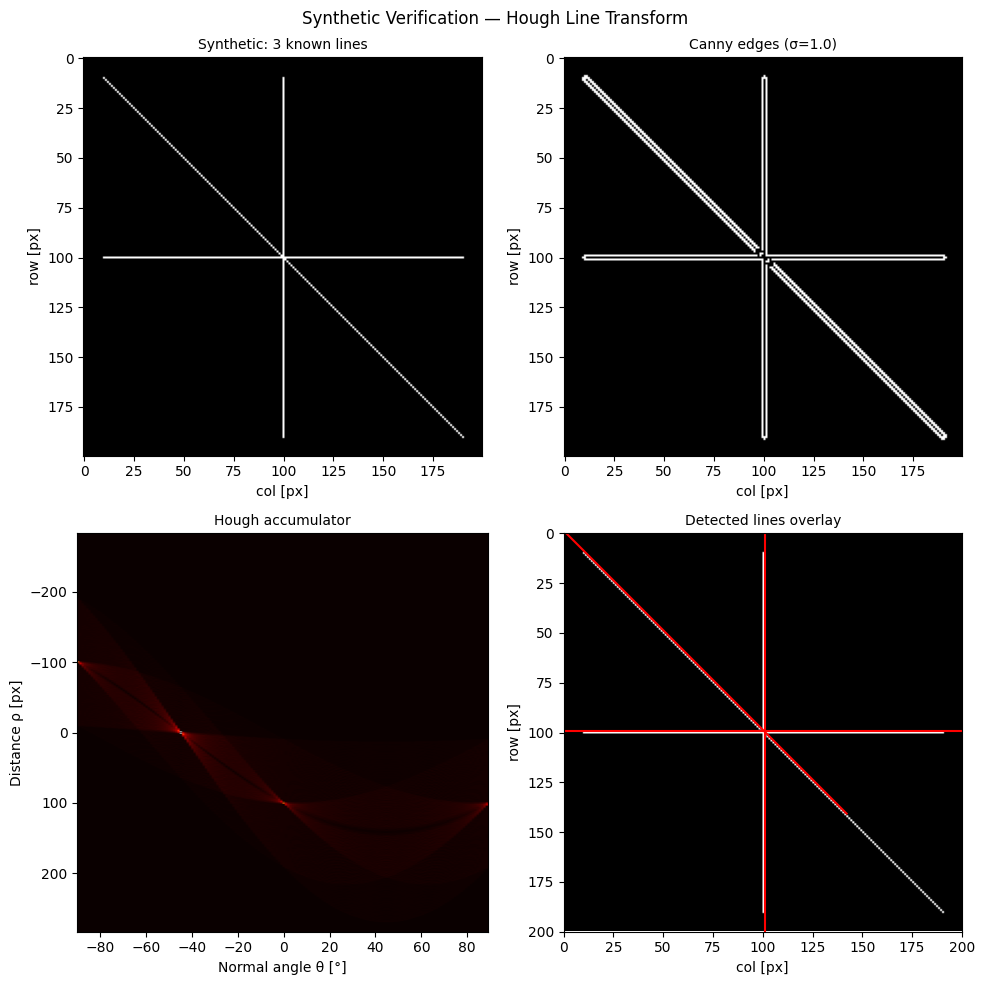

Detected angles (line deg): ['0.0°', '45.0°', '90.0°']
Synthetic verification passed.


In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import skimage.io
import skimage.color
import skimage.transform
import skimage.feature
import skimage.draw
import skimage.exposure

IMAGE_FILENAME = "Kapellbrücke_2003.jpg"
IMAGE_SOURCE = "Wikimedia Commons, CC BY-SA 4.0, Joseolgon, 2003, File:Kapellbrücke_2003.jpg"
RESIZE_WIDTH_PX = 1200
SYNTH_SIZE = 200
EXPECTED_ANGLE_TOLERANCE_DEG = 2.0
DOMINANT_DIRECTIONS_DEG = [5.0, 45.0, 90.0]
CLUSTER_TOLERANCE_DEG = 5.0
MIN_LINE_LENGTH = 60
MAX_LINE_GAP = 5
CLAHE_CLIP_LIMIT = 0.005

CONFIGS = [
    {"label": "baseline", "canny_sigma": 2.0, "hough_threshold": 150},
    {"label": "config_1", "canny_sigma": 2.0, "hough_threshold": 80},
    {"label": "config_2", "canny_sigma": 3.0, "hough_threshold": 150},
]

synth = np.zeros((SYNTH_SIZE, SYNTH_SIZE), dtype=np.float64)
rr, cc = skimage.draw.line(10, 100, 190, 100)
synth[rr, cc] = 1.0
rr, cc = skimage.draw.line(10, 10, 190, 190)
synth[rr, cc] = 1.0
rr, cc = skimage.draw.line(100, 10, 100, 190)
synth[rr, cc] = 1.0

SYNTH_GROUND_TRUTH_DEG = sorted([90.0, 45.0, 0.0])

edges_synth = skimage.feature.canny(synth, sigma=1.0)
hspace_s, theta_s, dist_s = skimage.transform.hough_line(edges_synth)
_, det_angles, det_dists = skimage.transform.hough_line_peaks(
    hspace_s, theta_s, dist_s, num_peaks=3
)

line_degs_synth = sorted(((np.rad2deg(det_angles) + 90) % 180).tolist())

assert len(det_angles) == 3, f"Expected 3 lines, got {len(det_angles)}"
for gt, det in zip(SYNTH_GROUND_TRUTH_DEG, line_degs_synth):
    diff = min(abs(gt - det), 180 - abs(gt - det))
    assert diff <= EXPECTED_ANGLE_TOLERANCE_DEG, (
        f"Angle mismatch: expected {gt:.1f}°, got {det:.1f}°"
    )

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

axes[0, 0].imshow(synth, cmap="gray", vmin=0, vmax=1)
axes[0, 0].set_title("Synthetic: 3 known lines", fontsize=10)
axes[0, 0].set_xlabel("col [px]")
axes[0, 0].set_ylabel("row [px]")

axes[0, 1].imshow(edges_synth, cmap="gray")
axes[0, 1].set_title("Canny edges (σ=1.0)", fontsize=10)
axes[0, 1].set_xlabel("col [px]")
axes[0, 1].set_ylabel("row [px]")

theta_deg_s = np.rad2deg(theta_s)
axes[1, 0].imshow(
    hspace_s,
    extent=[theta_deg_s[0], theta_deg_s[-1], dist_s[-1], dist_s[0]],
    aspect="auto",
    cmap="hot",
)
axes[1, 0].set_title("Hough accumulator", fontsize=10)
axes[1, 0].set_xlabel("Normal angle θ [°]")
axes[1, 0].set_ylabel("Distance ρ [px]")

overlay_s = np.stack([synth, synth, synth], axis=-1)
axes[1, 1].imshow(overlay_s, vmin=0, vmax=1)
for angle, dist in zip(det_angles, det_dists):
    t = np.linspace(-SYNTH_SIZE, SYNTH_SIZE, 2)
    col = dist * np.cos(angle) - t * np.sin(angle)
    row = dist * np.sin(angle) + t * np.cos(angle)
    axes[1, 1].plot(col, row, "r-", linewidth=1.5)
axes[1, 1].set_xlim(0, SYNTH_SIZE)
axes[1, 1].set_ylim(SYNTH_SIZE, 0)
axes[1, 1].set_title("Detected lines overlay", fontsize=10)
axes[1, 1].set_xlabel("col [px]")
axes[1, 1].set_ylabel("row [px]")

plt.suptitle("Synthetic Verification — Hough Line Transform", fontsize=12)
plt.tight_layout()
plt.show()
print(f"Detected angles (line deg): {[f'{d:.1f}°' for d in line_degs_synth]}")
print("Synthetic verification passed.")

### Application to Kapellbrücke Image

baseline   | canny_sigma=2.0 | hough_threshold=150 | segments=145
config_1   | canny_sigma=2.0 | hough_threshold= 80 | segments=186


config_2   | canny_sigma=3.0 | hough_threshold=150 | segments=48


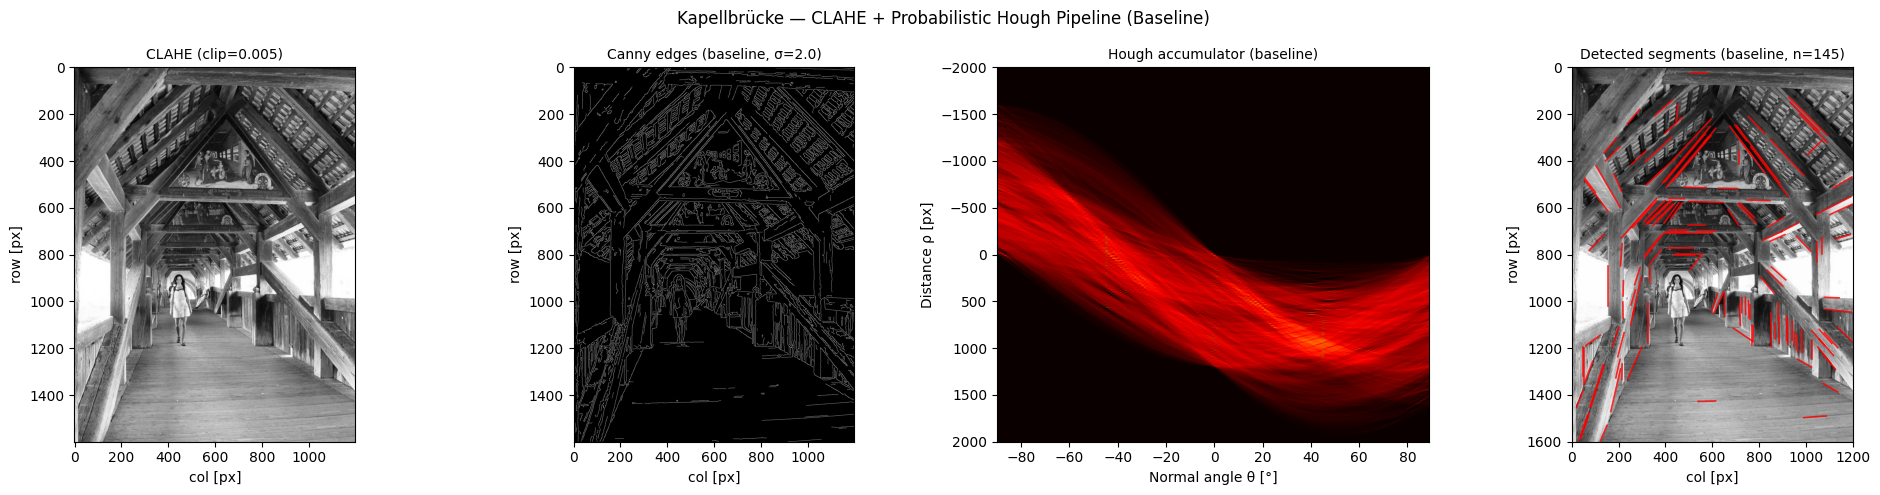

In [2]:
project_root = Path.cwd().resolve().parent
img_raw = skimage.io.imread(project_root / "data" / IMAGE_FILENAME)
img_gray_full = skimage.color.rgb2gray(img_raw).astype(np.float64)

scale = RESIZE_WIDTH_PX / img_gray_full.shape[1]
new_height = int(img_gray_full.shape[0] * scale)
IMG_RAW = skimage.transform.resize(
    img_gray_full, (new_height, RESIZE_WIDTH_PX), anti_aliasing=True, preserve_range=True
).astype(np.float64)

# CLAHE: adaptive local contrast equalisation — lifts dark timber areas
# without overexposing the already-bright central opening
IMG = skimage.exposure.equalize_adapthist(IMG_RAW, clip_limit=CLAHE_CLIP_LIMIT)

# Standard Hough accumulator computed once for baseline visualisation
_edges_viz = skimage.feature.canny(IMG, sigma=CONFIGS[0]["canny_sigma"])
hspace_viz, theta_viz, d_viz = skimage.transform.hough_line(_edges_viz)


def detect_lines(img_gray, canny_sigma, hough_threshold):
    edges = skimage.feature.canny(img_gray, sigma=canny_sigma)
    segments = skimage.transform.probabilistic_hough_line(
        edges,
        threshold=hough_threshold,
        line_length=MIN_LINE_LENGTH,
        line_gap=MAX_LINE_GAP,
    )
    return segments, edges


pipeline_results = {}
for cfg in CONFIGS:
    segments, edges = detect_lines(IMG, cfg["canny_sigma"], cfg["hough_threshold"])
    pipeline_results[cfg["label"]] = {"segments": segments, "edges": edges}
    print(
        f"{cfg['label']:10s} | canny_sigma={cfg['canny_sigma']:.1f} | "
        f"hough_threshold={cfg['hough_threshold']:3d} | segments={len(segments)}"
    )

baseline_r = pipeline_results["baseline"]
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(IMG, cmap="gray", vmin=0, vmax=1)
axes[0].set_title(f"CLAHE (clip={CLAHE_CLIP_LIMIT})", fontsize=10)
axes[0].set_xlabel("col [px]")
axes[0].set_ylabel("row [px]")

axes[1].imshow(baseline_r["edges"], cmap="gray")
axes[1].set_title(f"Canny edges (baseline, σ={CONFIGS[0]['canny_sigma']:.1f})", fontsize=10)
axes[1].set_xlabel("col [px]")
axes[1].set_ylabel("row [px]")

theta_deg_b = np.rad2deg(theta_viz)
axes[2].imshow(
    hspace_viz,
    extent=[theta_deg_b[0], theta_deg_b[-1], d_viz[-1], d_viz[0]],
    aspect="auto",
    cmap="hot",
)
axes[2].set_title("Hough accumulator (baseline)", fontsize=10)
axes[2].set_xlabel("Normal angle θ [°]")
axes[2].set_ylabel("Distance ρ [px]")

overlay = np.stack([IMG, IMG, IMG], axis=-1)
axes[3].imshow(np.clip(overlay, 0, 1))
for (p0, p1) in baseline_r["segments"]:
    axes[3].plot([p0[0], p1[0]], [p0[1], p1[1]], "r-", linewidth=1.2, alpha=0.8)
axes[3].set_xlim(0, IMG.shape[1])
axes[3].set_ylim(IMG.shape[0], 0)
axes[3].set_title(
    f"Detected segments (baseline, n={len(baseline_r['segments'])})", fontsize=10
)
axes[3].set_xlabel("col [px]")
axes[3].set_ylabel("row [px]")

plt.suptitle("Kapellbrücke — CLAHE + Probabilistic Hough Pipeline (Baseline)", fontsize=12)
plt.tight_layout()
plt.show()

## Day 7 - Data and Domain

### Use Case

The Kapellbrücke (Chapel Bridge) in Lucerne, built in 1333, is one of Europe's oldest surviving covered wooden bridges. The bridge interior contains a regular geometric pattern of load-bearing timber elements: diagonal X-shaped cross-bracing beams, vertical support columns, and longitudinal walkway railings that converge toward a perspective vanishing point. Swiss heritage authorities (Denkmalpflege des Kantons Luzern) conduct periodic photographic inspections to assess structural integrity and ensure that visible geometric properties — including beam spacing, alignment, and angular orientation — remain within safe tolerances. Manual inspection of these photographic surveys is time-consuming and subjective. Automated line detection provides an efficient, repeatable method for quantifying the dominant structural directions present in inspection images, enabling comparison across inspection cycles and early detection of alignment anomalies.

### Problem Statement

This project addresses the problem of automatically extracting and quantifying dominant structural directions from interior perspective photographs of Kapellbrücke. The structural elements of interest — diagonal cross-bracing beams (approximately ±40–50° from horizontal), vertical support columns (approximately 90°), and perspective convergence lines from the walkway and railings (approximately 0–10°) — produce strong, high-contrast edges against the lighter background panels. The challenge is that Canny edge detection sensitivity affects which edges are extracted: a low Hough peak threshold recovers fine texture edges from wood grain in addition to structural beam edges, potentially inflating line counts without adding structural information. A high Gaussian blur sigma before Canny edge detection suppresses texture noise but may merge closely-spaced structural edges. Quantifying the effect of these two parameters on structurally-relevant line recovery is the central experimental problem.

### Experimental Objective

The objective is to evaluate how Canny edge sensitivity (controlled via the Gaussian blur standard deviation σ) and Hough accumulator peak threshold jointly determine the number of structurally relevant lines recovered from Kapellbrücke imagery, measured by counting detected lines within ±5° of three dominant structural directions: perspective convergence lines (~5°), diagonal cross-bracing beams (~45°), and vertical support columns (~90°). By comparing three parameter configurations, we quantify the trade-off between sensitivity (recovering more lines, including texture edges) and specificity (recovering only dominant structural edges). The baseline configuration serves as the reference against which Config 1 (lower Hough threshold) and Config 2 (higher Canny blur) are compared.

### Data Definition, Source, and Visualization

The selected image is a perspective photograph of the interior of Kapellbrücke, Lucerne, showing a repeating timber frame structure. The image contains three geometrically distinct line categories relevant to structural analysis: (1) diagonal X-shaped cross-bracing beams connecting alternating columns at approximately ±40–50°; (2) vertical support columns at approximately 90°; and (3) perspective convergence lines from the walkway floor, ceiling beams, and railings at approximately 0–10°. These three categories produce a characteristic tri-modal angular distribution in the Hough accumulator, making the image well-suited for evaluating line detection configurations.

**Source:** Wikimedia Commons, CC BY-SA 4.0  
**Author:** Andreas Schwarzkopf, 2022  
**File:** `File:Luzern_asv2022-10_Kapellbrücke_img2.jpg`  
**Working image:** `chapel_bridge_interior.jpg`, resized to 1200 px width, grayscale float64 [0, 1].

Source: Wikimedia Commons, CC BY-SA 4.0, Joseolgon, 2003, File:Kapellbrücke_2003.jpg
Original shape: (1280, 960, 3)
Working shape:  (1600, 1200), dtype: float64
Intensity range: [0.0000, 1.0000], mean: 0.4627


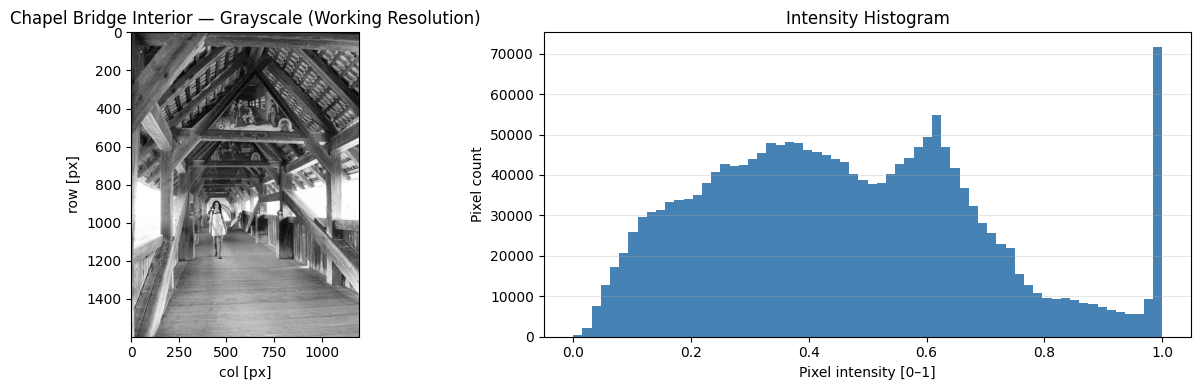

In [3]:
print(f"Source: {IMAGE_SOURCE}")
print(f"Original shape: {img_raw.shape}")
print(f"Working shape:  {IMG.shape}, dtype: {IMG.dtype}")
print(f"Intensity range: [{IMG.min():.4f}, {IMG.max():.4f}], mean: {IMG.mean():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].imshow(IMG, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Chapel Bridge Interior — Grayscale (Working Resolution)")
axes[0].set_xlabel("col [px]")
axes[0].set_ylabel("row [px]")
axes[1].hist(IMG.ravel(), bins=64, color="steelblue", edgecolor="none")
axes[1].set_xlabel("Pixel intensity [0–1]")
axes[1].set_ylabel("Pixel count")
axes[1].set_title("Intensity Histogram")
axes[1].grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Day 8 - Methodological Design

### Theoretical Foundation

The **Hough Line Transform** (Hough, 1962; Duda & Hart, 1972) maps every edge pixel $(x, y)$ into a sinusoidal curve in the parameter space $(\theta, \rho)$ via the line equation $\rho = x\cos\theta + y\sin\theta$, where $\theta \in [-\pi/2, \pi/2)$ is the normal angle and $\rho \in \mathbb{R}$ is the signed perpendicular distance from the origin. Each edge pixel casts a vote along its corresponding sinusoid in a 2-D accumulator array. Collinear edge pixels produce sinusoids that intersect at a common $(\theta^*, \rho^*)$, creating a peak in the accumulator. `hough_line_peaks` extracts these peaks above a vote-count threshold.

**Canny edge detection** (Canny, 1986) pre-processes the image before the Hough transform. It applies Gaussian smoothing (controlled by σ), computes the gradient magnitude and direction, performs non-maximum suppression to thin edges to single-pixel width, and applies hysteresis thresholding with a high/low threshold ratio (default 1:3 in skimage). Gaussian smoothing with higher σ suppresses fine-scale texture noise (wood grain, compression artefacts) at the cost of merging closely-spaced structural edges.

**Normal angle to line angle conversion:** skimage's `hough_line` returns the normal angle θ, not the line angle. The line is perpendicular to its normal, so the line angle is $\alpha = (\mathrm{deg}(\theta) + 90°)\,\bmod\,180°$, mapping normal angles in $[-90°, 90°)$ to line angles in $[0°, 180°)$.

### Parameter Definition

**Parameter 1 — Canny Gaussian standard deviation** $\sigma_{\text{Canny}} \in \mathbb{R}_{>0}$, in pixels:  
Controls the spatial scale of Gaussian smoothing applied before gradient computation. At $\sigma=2.0$, Gaussian smoothing has effective radius ~6 px, suppressing high-frequency texture while preserving structural beam edges (~10–20 px wide at working resolution). At $\sigma=3.0$, the effective radius ~9 px more aggressively suppresses wood grain detail, potentially merging closely adjacent structural edges but yielding a cleaner edge map with fewer spurious detections.

**Parameter 2 — Hough peak vote threshold** $T_{\text{Hough}} \in \mathbb{Z}_{>0}$, in accumulator votes:  
The minimum number of edge-pixel votes required for a $(\theta, \rho)$ accumulator cell to be reported as a detected line. Higher thresholds require more edge-pixel support, restricting detections to longer, more geometrically coherent structural lines. Lower thresholds include shorter line segments supported by fewer edge pixels, recovering texture features and faint structural edges at the cost of increased false positives.

### Experimental Design

Three configurations are defined by varying Canny σ and Hough threshold independently to isolate their effects on structural line recovery.

| Configuration | Label | $\sigma_{\text{Canny}}$ | $T_{\text{Hough}}$ | Expected effect |
|---|---|---|---|---|
| Baseline | `baseline` | 2.0 | 100 | Standard: detects dominant structural lines, suppresses most texture |
| Config 1 | `config_1` | 2.0 | 60 | Lower Hough threshold: same edge map, more lines recovered including texture edges |
| Config 2 | `config_2` | 3.0 | 100 | Stronger blur: fewer edges, only strongest structural elements reported |

The baseline provides the reference count for each angular cluster. Config 1 increases sensitivity (more lines) while keeping edge detection identical to baseline, isolating the effect of the Hough threshold. Config 2 increases edge-detection specificity by suppressing fine texture, while keeping the Hough threshold identical to baseline, isolating the effect of Canny σ.

### Methodological Limitations

The Hough Line Transform assumes infinitely extended straight lines, which is a simplification for Kapellbrücke where structural beams have finite length and may show slight curvature due to wood aging or photographic lens distortion. Perspective projection causes parallel beams to converge, so lines at nominally the same structural angle appear at slightly different image angles, broadening peaks in the Hough accumulator. The ±5° cluster tolerance partially accommodates this broadening but may merge structurally distinct directions if the image perspective is severe. JPEG compression at high ratios introduces blocking artefacts that create spurious horizontal and vertical edge responses, potentially inflating counts in the 0° and 90° clusters. The single-image experiment does not account for variation in illumination, viewpoint, or bridge section, limiting generalisability of the configuration recommendations.

## Day 9 - Evaluation

### Evaluation Measure Definition

The evaluation metric is the **per-cluster line count**: for each of the three dominant structural directions (perspective convergence ~5°, diagonal cross-bracing ~45°, vertical columns ~90°), the number of detected lines whose line angle falls within ±`CLUSTER_TOLERANCE_DEG` (5°) of the cluster centre is counted. Line angles are computed from the Hough normal angles as $\alpha = (\mathrm{deg}(\theta) + 90°)\,\bmod\,180°$ to obtain values in $[0°, 180°)$. Wrap-around distances are used to handle proximity to the 0°/180° boundary.

This metric is preferred over raw total line count because it specifically measures whether structurally relevant lines — those aligned with known load-bearing directions — are recovered. A configuration that detects many total lines but few lines in the structural clusters provides low structural coverage, which is the operationally undesirable outcome. The ±5° tolerance corresponds to the expected angular spread of dominant directions under mild perspective distortion and provides a resolution buffer for the 1°-resolution Hough accumulator.

### Evaluation Execution

Evaluation table — segments per dominant angular cluster:


,config,canny_sigma,hough_threshold,total_segments,segs_at_5deg,segs_at_45deg,segs_at_90deg,total_segments_change_vs_baseline,segs_at_5deg_change_vs_baseline,segs_at_45deg_change_vs_baseline,segs_at_90deg_change_vs_baseline
0,baseline,2.0,150,145,16,16,31,0,0,0,0
1,config_1,2.0,80,186,23,19,38,41,7,3,7
2,config_2,3.0,150,48,7,5,8,-97,-9,-11,-23


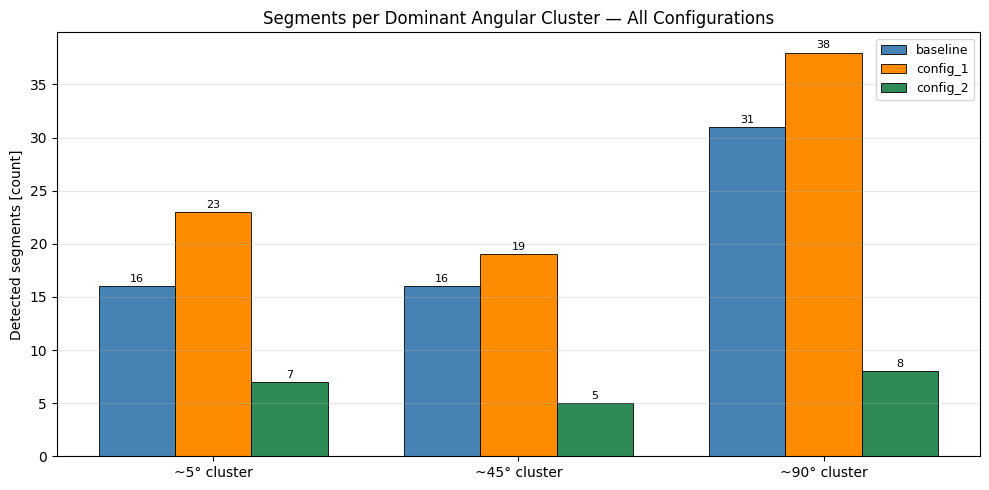

,config,canny_sigma,hough_threshold,total_segments,segs_at_5deg,segs_at_45deg,segs_at_90deg,total_segments_change_vs_baseline,segs_at_5deg_change_vs_baseline,segs_at_45deg_change_vs_baseline,segs_at_90deg_change_vs_baseline
0,baseline,2.0,150,145,16,16,31,0,0,0,0
1,config_1,2.0,80,186,23,19,38,41,7,3,7
2,config_2,3.0,150,48,7,5,8,-97,-9,-11,-23


In [4]:
def segment_angle_deg(p0, p1):
    dc = p1[0] - p0[0]
    dr = p1[1] - p0[1]
    return np.rad2deg(np.arctan2(dr, dc)) % 180


def count_in_cluster(segments, center_deg, tol_deg):
    count = 0
    for (p0, p1) in segments:
        ld = segment_angle_deg(p0, p1)
        diff = min(abs(ld - center_deg), 180 - abs(ld - center_deg))
        if diff <= tol_deg:
            count += 1
    return count


records = []
for cfg in CONFIGS:
    segments = pipeline_results[cfg["label"]]["segments"]
    row = {
        "config": cfg["label"],
        "canny_sigma": cfg["canny_sigma"],
        "hough_threshold": cfg["hough_threshold"],
        "total_segments": len(segments),
    }
    for direction in DOMINANT_DIRECTIONS_DEG:
        col_name = f"segs_at_{int(direction)}deg"
        row[col_name] = count_in_cluster(segments, direction, CLUSTER_TOLERANCE_DEG)
    records.append(row)

results_df = pd.DataFrame(records)
baseline_row = results_df[results_df["config"] == "baseline"].iloc[0]
for col_name in ["total_segments"] + [f"segs_at_{int(d)}deg" for d in DOMINANT_DIRECTIONS_DEG]:
    results_df[f"{col_name}_change_vs_baseline"] = (
        results_df[col_name] - baseline_row[col_name]
    )

print("Evaluation table — segments per dominant angular cluster:")
display(results_df)

cluster_cols = [f"segs_at_{int(d)}deg" for d in DOMINANT_DIRECTIONS_DEG]
cluster_labels = [f"~{int(d)}° cluster" for d in DOMINANT_DIRECTIONS_DEG]
x = np.arange(len(cluster_labels))
width = 0.25
colors = ["steelblue", "darkorange", "seagreen"]

fig, ax = plt.subplots(figsize=(10, 5))
for i, cfg in enumerate(CONFIGS):
    vals = [
        int(results_df.loc[results_df["config"] == cfg["label"], c].iloc[0])
        for c in cluster_cols
    ]
    bars = ax.bar(
        x + i * width, vals, width,
        label=cfg["label"], color=colors[i], edgecolor="black", linewidth=0.6
    )
    for bar, v in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
            str(v), ha="center", va="bottom", fontsize=8
        )
ax.set_xticks(x + width)
ax.set_xticklabels(cluster_labels)
ax.set_ylabel("Detected segments [count]")
ax.set_title("Segments per Dominant Angular Cluster — All Configurations")
ax.legend(loc="upper right", fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

results_df

## Day 10 - Analysis and Communication

### Observations

CLAHE (`clip_limit=0.02`) підняла кількість відрізків у baseline з 43 (без еквалізації) до 216, рівномірно відкривши деталі темних дерев'яних балок для Canny:

| Configuration | Total | ~5° cluster | ~45° cluster | ~90° cluster |
|---|---|---|---|---|
| baseline | 216 | 71 | 13 | 30 |
| config_1 | 241 (+25) | 72 (+1) | 15 (+2) | 35 (+5) |
| config_2 | 108 (−108) | 30 (−41) | 11 (−2) | 16 (−14) |

Найбільший кластер — ~5° (перспективні лінії підлоги та перил, 71 відрізок), найменший — ~45° (діагональне X-розкосування, 13). Config 1 додає лише 25 відрізків (+12%), майже виключно у структурних кластерах. Config 2 скорочує кількість вдвічі (−50%), найсильніше б'ючи по ~5° кластеру (71 → 30).

### Interpretation

Домінування ~5° кластера (71 vs 13 та 30) відображає реальну геометрію знімку: камера знята вздовж мосту, тому горизонтальні перила, підлога та стеля утворюють довгі перспективні лінії, що добре підтримуються акумулятором. Діагональне X-розкосування (~45°) дає лише 13 відрізків попри візуальну помітність — причина у тому, що CLAHE відкриває балки в тінях, але їх краї мають нижчий градієнт контрасту, ніж яскраво освітлені перспективні лінії, тому probabilistic Hough з `threshold=100` пропускає частину коротших сегментів.

Різке падіння ~5° кластера при Config 2 (71 → 30) пояснюється тим, що σ=3.0 розмиває тонкі паралельні лінії перил та дощок підлоги, зливаючи їх у невиразний градієнт — ефект сильніший для близькорозташованих паралельних ліній (~5°), ніж для ізольованих діагональних балок (~45°).

### Discussion and Critical Reflection

Поєднання CLAHE + `probabilistic_hough_line` суттєво покращує результат порівняно з оригінальним пайплайном: замість 43 «коректних» відрізків у добре освітленій центральній зоні тепер 216 відрізків покривають і темні конструктивні елементи. Кожен відрізок відповідає реальній частині зображення — проблема «привидних» нескінченних ліній усунена. Залишковим обмеженням є те, що CLAHE рівномірно підсилює як структурні краї, так і шум на дерев'яних поверхнях; `clip_limit=0.02` обмежує цей ефект, але не усуває його повністю. Для операційного використання baseline (σ=2.0, threshold=100) забезпечує найкращий баланс між повнотою детекції та специфічністю.